# **Predicting water quality index of the great lakes**

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports

Import required modules and setup environment for reproducabilitiy:

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox, zscore
from scipy.special import inv_boxcox
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from tensorflow import keras
from tensorflow.keras import layers, constraints
import os
import random


In [ ]:
# Set seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'
tf.config.experimental.enable_op_determinism()

In [ ]:
os.makedirs("/content/drive/MyDrive/figures", exist_ok=True)

In [ ]:
 pd.set_option('display.max_columns', None)

Load Dataset from Google Drive:

*   Google Drive must have dataset downloaded prior to run



In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset.csv')
df.head(10)

/tmp/ipykernel_439/4023740450.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/dataset.csv')


,DatasetName,MonitoringLocationID,MonitoringLocationName,MonitoringLocationLatitude,MonitoringLocationLongitude,MonitoringLocationHorizontalCoordinateReferenceSystem,MonitoringLocationHorizontalAccuracyMeasure,MonitoringLocationHorizontalAccuracyUnit,MonitoringLocationVerticalMeasure,MonitoringLocationVerticalUnit,MonitoringLocationType,ActivityType,ActivityMediaName,ActivityStartDate,ActivityStartTime,ActivityStartTimeZone,ActivityEndDate,ActivityEndTime,ActivityEndTimeZone,ActivityDepthHeightMeasure,ActivityDepthHeightUnit,SampleCollectionEquipmentName,CharacteristicName,MethodSpeciation,ResultSampleFraction,ResultValue,ResultUnit,ResultValueType,ResultDetectionCondition,ResultDetectionQuantitationLimitMeasure,ResultDetectionQuantitationLimitUnit,ResultDetectionQuantitationLimitType,ResultStatusID,ResultComment,ResultAnalyticalMethodID,ResultAnalyticalMethodContext,ResultAnalyticalMethodName,AnalysisStartDate,AnalysisStartTime,AnalysisStartTimeZone,LaboratoryName,LaboratorySampleID
0,Great Lakes Water Quality Monitoring and Surve...,887,Lake Erie,42.647,-79.692,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,Dissolved oxygen saturation,NaN,NaN,109.000000,%,Actual,NaN,NaN,NaN,NaN,NaN,NaN,247,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
1,Great Lakes Water Quality Monitoring and Surve...,934,Lake Erie,42.708,-79.508,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,Dissolved oxygen saturation,NaN,NaN,110.000000,%,Actual,NaN,NaN,NaN,NaN,NaN,NaN,247,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
2,Great Lakes Water Quality Monitoring and Surve...,932,Lake Erie,42.791,-79.208,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,pH,NaN,NaN,8.400000,NaN,Actual,NaN,NaN,NaN,NaN,NaN,NaN,213,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
3,Great Lakes Water Quality Monitoring and Surve...,932,Lake Erie,42.791,-79.208,NAD83,NaN,NaN,NaN,NaN,Great Lake,Field Msr/Obs,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,0.0,m,NaN,"Depth, Secchi disk depth",NaN,NaN,5.500000,m,Actual,NaN,NaN,NaN,NaN,NaN,NaN,30,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
4,Great Lakes Water Quality Monitoring and Surve...,934,Lake Erie,42.708,-79.508,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,Calcium,NaN,Dissolved,32.299999,ppm,Actual,NaN,NaN,NaN,NaN,NaN,NaN,325,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
5,Great Lakes Water Quality Monitoring and Surve...,933,Lake Erie,42.825,-79.567,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,pH,NaN,NaN,8.340000,NaN,Actual,NaN,NaN,NaN,NaN,NaN,NaN,213,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
6,Great Lakes Water Quality Monitoring and Surve...,933,Lake Erie,42.825,-79.567,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,Magnesium,NaN,Dissolved,8.940000,ppm,Actual,NaN,NaN,NaN,NaN,NaN,NaN,355,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
7,Great Lakes Water Quality Monitoring and Surve...,934,Lake Erie,42.708,-79.508,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,Magnesium,NaN,Dissolved,8.720000,ppm,Actual,NaN,NaN,NaN,NaN,NaN,NaN,355,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
8,Great Lakes Water Quality Monitoring and Surve...,932,Lake Erie,42.791,-79.208,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,Specific conductance,NaN,NaN,170.000000,uS/cm,Actual,NaN,NaN,NaN,NaN,NaN,NaN,160,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN
9,Great Lakes Water Quality Monitoring and Surve...,931,Lake Erie,42.849,-78.941,NAD83,NaN,NaN,NaN,NaN,Great Lake,Sample-Routine,Surface Water,4/16/2000,NaN,NaN,NaN,NaN,NaN,-1.0,m,NaN,Specific conductance,NaN,NaN,180.000000,uS/cm,Actual,NaN,NaN,NaN,NaN,NaN,NaN,160,ENV/CANADA,NaN,NaN,NaN,NaN,ECCCLabs,NaN


Print Dataset Information:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237326 entries, 0 to 237325
Data columns (total 42 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   DatasetName                                            237326 non-null  object 
 1   MonitoringLocationID                                   237326 non-null  object 
 2   MonitoringLocationName                                 237326 non-null  object 
 3   MonitoringLocationLatitude                             237326 non-null  float64
 4   MonitoringLocationLongitude                            237326 non-null  float64
 5   MonitoringLocationHorizontalCoordinateReferenceSystem  237326 non-null  object 
 6   MonitoringLocationHorizontalAccuracyMeasure            0 non-null       float64
 7   MonitoringLocationHorizontalAccuracyUnit               0 non-null       float64
 8   MonitoringLocationVerticalMeasure 

In [ ]:
df.isnull().sum()

,0
DatasetName,0
MonitoringLocationID,0
MonitoringLocationName,0
MonitoringLocationLatitude,0
MonitoringLocationLongitude,0
MonitoringLocationHorizontalCoordinateReferenceSystem,0
MonitoringLocationHorizontalAccuracyMeasure,237326
MonitoringLocationHorizontalAccuracyUnit,237326
MonitoringLocationVerticalMeasure,237326
MonitoringLocationVerticalUnit,237326


# Data preprocessing

Check how many unique MonitoringLocationID values are present:

In [ ]:
df['MonitoringLocationID'].nunique()

693

Drop any columns that have all null values:

In [ ]:
df_modified = df.dropna(axis=1, how='all').copy()
df_modified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237326 entries, 0 to 237325
Data columns (total 25 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   DatasetName                                            237326 non-null  object 
 1   MonitoringLocationID                                   237326 non-null  object 
 2   MonitoringLocationName                                 237326 non-null  object 
 3   MonitoringLocationLatitude                             237326 non-null  float64
 4   MonitoringLocationLongitude                            237326 non-null  float64
 5   MonitoringLocationHorizontalCoordinateReferenceSystem  237326 non-null  object 
 6   MonitoringLocationType                                 237326 non-null  object 
 7   ActivityType                                           237326 non-null  object 
 8   ActivityMediaName                 

Cast the columns to their datatypes as required:

In [ ]:
df_modified['ActivityStartDate'] = pd.to_datetime(df_modified['ActivityStartDate'])
df_modified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237326 entries, 0 to 237325
Data columns (total 25 columns):
 #   Column                                                 Non-Null Count   Dtype         
---  ------                                                 --------------   -----         
 0   DatasetName                                            237326 non-null  object        
 1   MonitoringLocationID                                   237326 non-null  object        
 2   MonitoringLocationName                                 237326 non-null  object        
 3   MonitoringLocationLatitude                             237326 non-null  float64       
 4   MonitoringLocationLongitude                            237326 non-null  float64       
 5   MonitoringLocationHorizontalCoordinateReferenceSystem  237326 non-null  object        
 6   MonitoringLocationType                                 237326 non-null  object        
 7   ActivityType                                           2

Group rows that have the same CharacteristicName and ResultUnit:

In [ ]:
df_modified.groupby(['CharacteristicName', 'ResultUnit']).size()

,,0
CharacteristicName,ResultUnit,
"Alkalinity, total",mg/L,9358
Aluminum,ug/L,391
Ammonia,mg/L,3693
Antimony,ug/L,391
Arsenic,ug/L,391
...,...,...
Turbidity,NTU,2595
Uranium,ug/L,391
Vanadium,ug/L,391


In [ ]:
df_modified['CharacteristicName'] = df_modified.apply(
    lambda row: row['CharacteristicName'] + ' (' + row['ResultUnit'] + ')'
    if pd.notna(row['ResultUnit'])
    else row['CharacteristicName'],
    axis=1
)

Pivot the data

In [ ]:
dataset = df_modified.pivot_table(index=['MonitoringLocationID', 'ActivityStartDate', 'MonitoringLocationName'], columns='CharacteristicName', values='ResultValue')
dataset.head(100)

CharacteristicName                                             Alkalinity, total (mg/L)  \
MonitoringLocationID ActivityStartDate MonitoringLocationName                             
1                    2000-05-01        Lake Huron                                   NaN   
                     2000-05-08        Georgian Bay                                 NaN   
                     2000-08-17        Lake Huron                                   NaN   
                     2000-08-24        Georgian Bay                                 NaN   
                     2001-04-02        Lake Ontario                                 NaN   
...                                                                                 ...   
3                    2000-05-08        Georgian Bay                                 NaN   
                     2000-08-17        Lake Huron                                   NaN   
                     2000-08-24        Georgian Bay                                 NaN   
                     2001-04-02        Lake Ontario                                 NaN   
                     2001-07-30        Lake Ontario                                 NaN   

CharacteristicName                                             Aluminum (ug/L)  \
MonitoringLocationID ActivityStartDate MonitoringLocationName                    
1                    2000-05-01        Lake Huron                          NaN   
                     2000-05-08        Georgian Bay                        NaN   
                     2000-08-17        Lake Huron                          NaN   
                     2000-08-24        Georgian Bay                        NaN   
                     2001-04-02        Lake Ontario                        NaN   
...                                                                        ...   
3                    2000-05-08        Georgian Bay                        NaN   
                     2000-08-17        Lake Huron                          NaN   
                     2000-08-24        Georgian Bay                        NaN   
                     2001-04-02        Lake Ontario                        NaN   
                     2001-07-30        Lake Ontario                        NaN   

CharacteristicName                                             Ammonia (mg/L)  \
MonitoringLocationID ActivityStartDate MonitoringLocationName                   
1                    2000-05-01        Lake Huron                       0.007   
                     2000-05-08        Georgian Bay                     0.003   
                     2000-08-17        Lake Huron                         NaN   
                     2000-08-24        Georgian Bay                       NaN   
                     2001-04-02        Lake Ontario                     0.015   
...                                                                       ...   
3                    2000-05-08        Georgian Bay                     0.002   
                     2000-08-17        Lake Huron                         NaN   
                     2000-08-24        Georgian Bay                       NaN   
                     2001-04-02        Lake Ontario                       NaN   
                     2001-07-30        Lake Ontario                       NaN   

CharacteristicName                                             Antimony (ug/L)  \
MonitoringLocationID ActivityStartDate MonitoringLocationName                    
1                    2000-05-01        Lake Huron                          NaN   
                     2000-05-08        Georgian Bay                        NaN   
                     2000-08-17        Lake Huron                          NaN   
                     2000-08-24        Georgian Bay                        NaN   
                     2001-04-02        Lake Ontario                        NaN   
...                                                                        ...   
3                    2000-05-08        

Calculate the proportion of null values in each column:

In [ ]:
dataset.isnull().mean().sort_values(ascending=False)

,0
CharacteristicName,
Platinum (ug/L),0.999695
Niobium (ug/L),0.989313
Bismuth (ug/L),0.988397
Tin (ug/L),0.980611
Silver (ug/L),0.979695
...,...
pH,0.090076
Organic carbon (mg/L),0.086870
"Chlorophyll a, uncorrected for pheophytin (ug/L)",0.080153


Drop columns with missing values greater than 50%:



In [ ]:
dataset = dataset.dropna(axis=1, thresh=len(dataset) * 0.5)
dataset.isnull().mean().sort_values(ascending=False)

,0
CharacteristicName,
Sulfate (mg/L),0.497099
Chloride (mg/L),0.496947
Fluoride (mg/L),0.496794
Inorganic nitrogen (nitrate and nitrite) (mg/L),0.476641
Soluble Reactive Phosphorus (SRP) (mg/L),0.476031
"Alkalinity, total (mg/L)",0.258015
"Chlorophyll a, corrected for pheophytin (ug/L)",0.202137
Dissolved oxygen saturation (%),0.169618
"Silica, reactive (mg/L)",0.121221


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6550 entries, (1, Timestamp('2000-05-01 00:00:00'), 'Lake Huron') to ('99', Timestamp('2018-09-15 00:00:00'), 'Lake Huron')
Data columns (total 18 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Alkalinity, total (mg/L)                          4860 non-null   float64
 1   Chloride (mg/L)                                   3295 non-null   float64
 2   Chlorophyll a, corrected for pheophytin (ug/L)    5226 non-null   float64
 3   Chlorophyll a, uncorrected for pheophytin (ug/L)  6025 non-null   float64
 4   Dissolved oxygen (DO) (mg/L)                      5765 non-null   float64
 5   Dissolved oxygen saturation (%)                   5439 non-null   float64
 6   Fluoride (mg/L)                                   3296 non-null   float64
 7   Inorganic nitrogen (nitrate and nitrite) (mg/L)   3428 non-null   float64
 8 

Get the predictor columns:

In [ ]:
predictors = dataset.columns.tolist()
predictors

['Alkalinity, total (mg/L)',
 'Chloride (mg/L)',
 'Chlorophyll a, corrected for pheophytin (ug/L)',
 'Chlorophyll a, uncorrected for pheophytin (ug/L)',
 'Dissolved oxygen (DO) (mg/L)',
 'Dissolved oxygen saturation (%)',
 'Fluoride (mg/L)',
 'Inorganic nitrogen (nitrate and nitrite) (mg/L)',
 'Kjeldahl nitrogen (mg/L)',
 'Organic carbon (mg/L)',
 'Silica, reactive (mg/L)',
 'Soluble Reactive Phosphorus (SRP) (mg/L)',
 'Specific conductance (uS/cm)',
 'Sulfate (mg/L)',
 'Temperature, water (deg C)',
 'Total Nitrogen, mixed forms (mg/L)',
 'Total Phosphorus, mixed forms (mg/L)',
 'pH']

Check for correlation between the predictors:

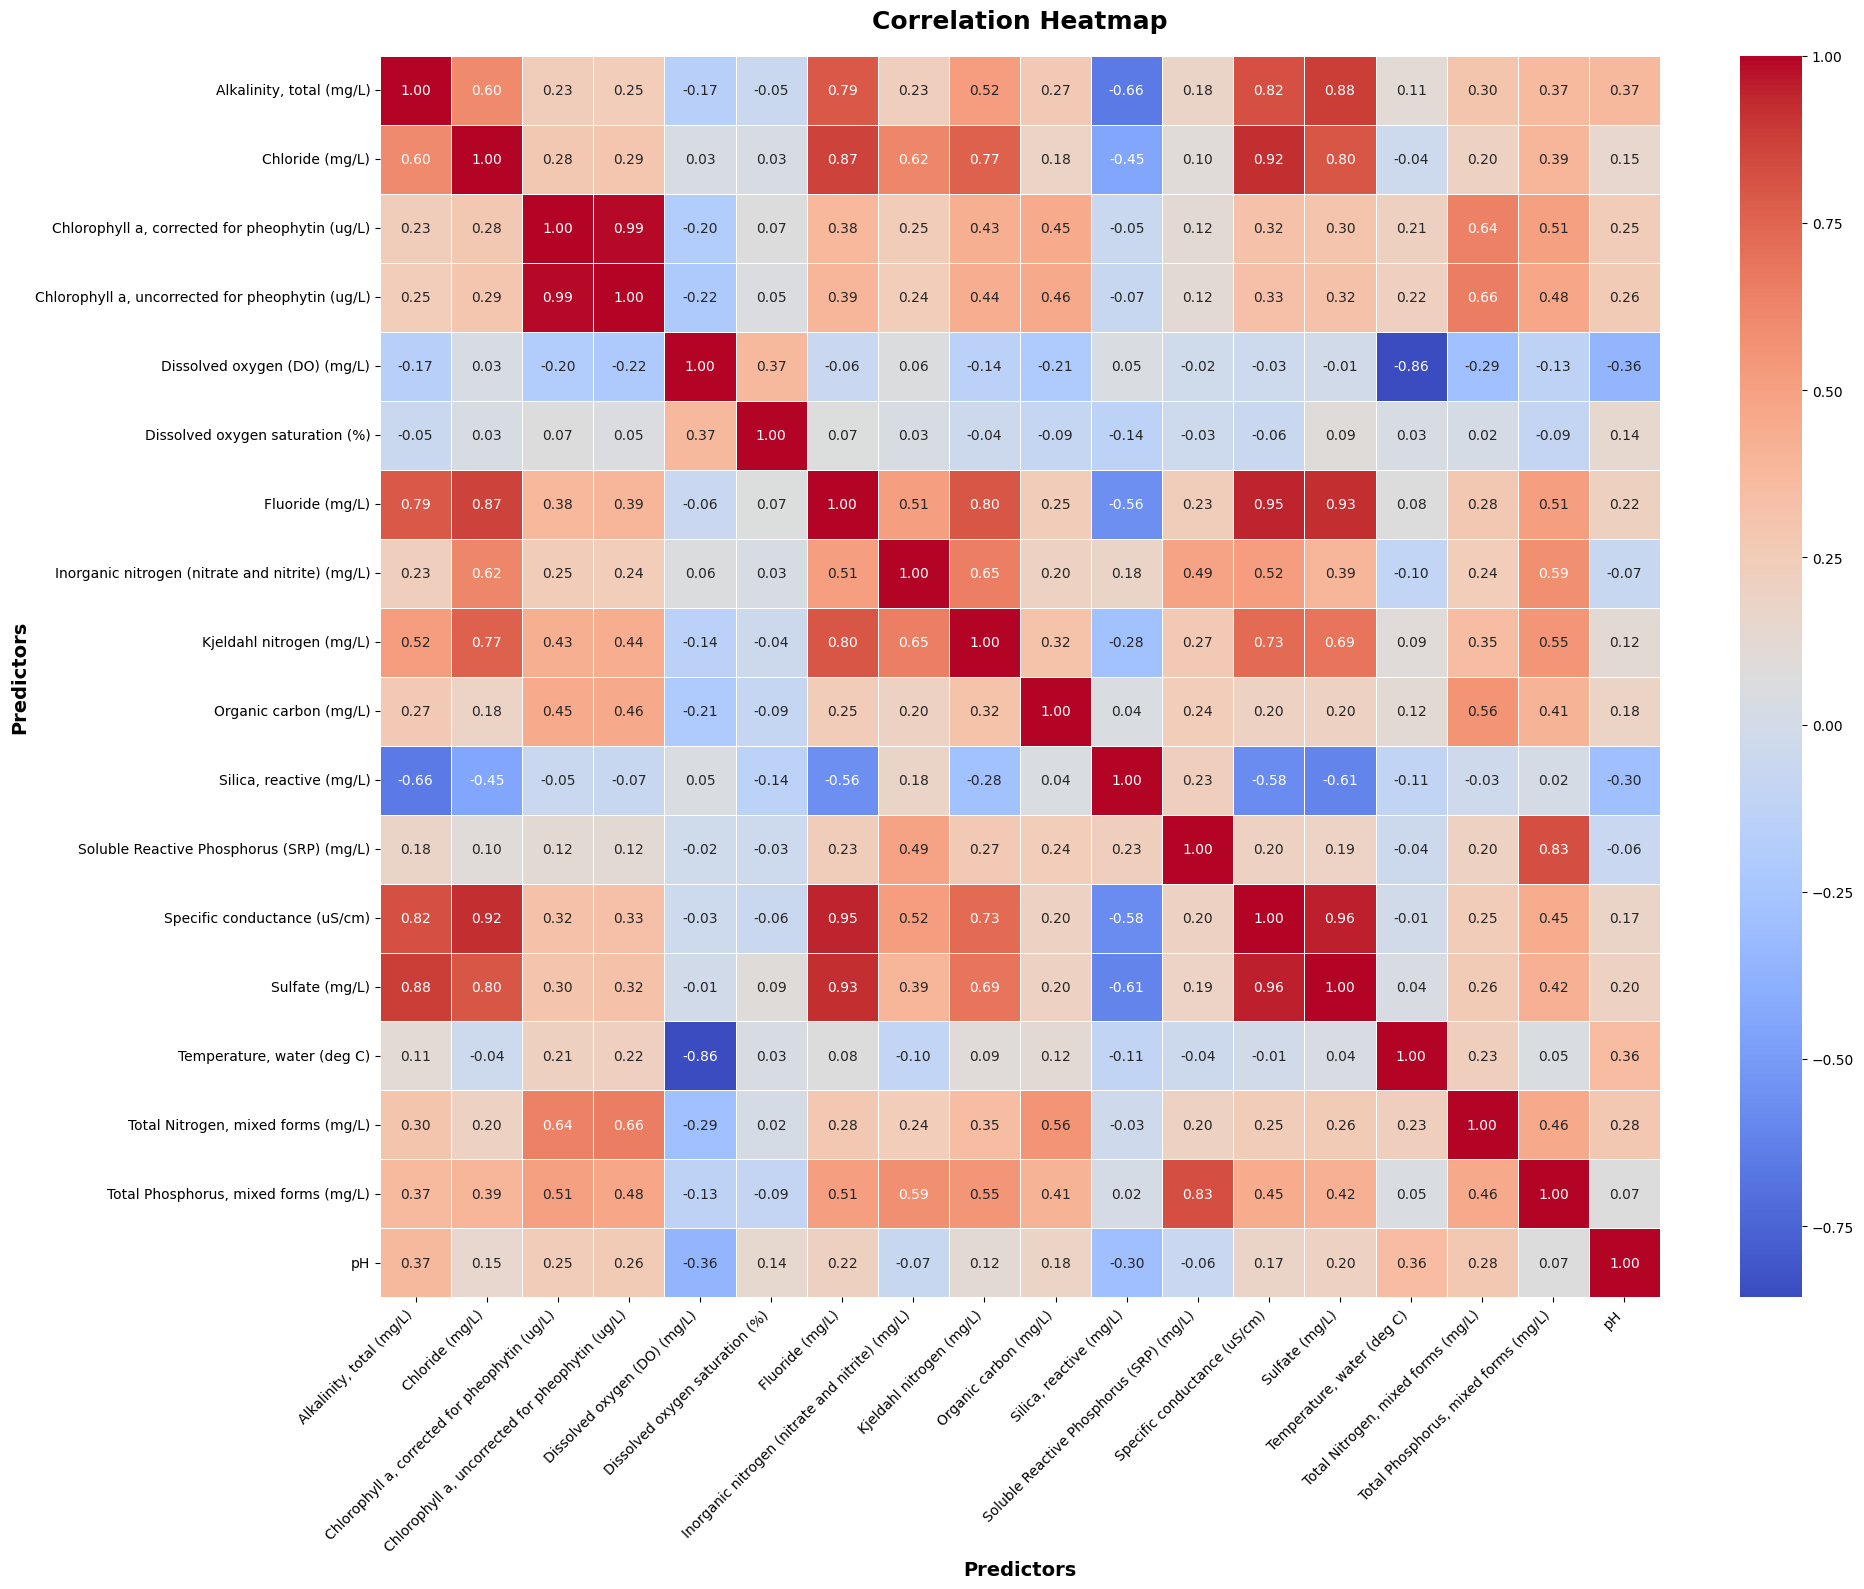

In [ ]:
corr_matrix = dataset[predictors].corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size': 10}, linewidths=0.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.xlabel('Predictors', fontsize=14, weight='bold')
plt.ylabel('Predictors', fontsize=14, weight='bold')
plt.title('Correlation Heatmap', fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/figures/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

Print predictors with correlation > 0.9:

In [ ]:
threshold = 0.9

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper.columns for row in upper.index if abs(upper[col][row]) > threshold]

for col, row in high_corr_pairs:
    print(f"{row} <-> {col} : {corr_matrix[col][row]:.2f}")

Chlorophyll a, corrected for pheophytin (ug/L) <-> Chlorophyll a, uncorrected for pheophytin (ug/L) : 0.99
Chloride (mg/L) <-> Specific conductance (uS/cm) : 0.92
Fluoride (mg/L) <-> Specific conductance (uS/cm) : 0.95
Fluoride (mg/L) <-> Sulfate (mg/L) : 0.93
Specific conductance (uS/cm) <-> Sulfate (mg/L) : 0.96


Drop highly correlated predictors (one from each pair):

In [ ]:
high_corr_predictors = [
    'Chlorophyll a, corrected for pheophytin (ug/L)',
    'Specific conductance (uS/cm)',
    'Fluoride (mg/L)',
    'Sulfate (mg/L)'
]

#dataset_corr_filter = dataset.drop(columns=high_corr_predictors)
dataset_corr_filter = dataset

#predictors = [col for col in predictors if col not in high_corr_predictors]
predictors = [col for col in predictors]

Scale the predictors:

In [ ]:
X = dataset_corr_filter[predictors].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Impute the missing values:

In [ ]:
imputer = KNNImputer(n_neighbors=10)
X_imputed = imputer.fit_transform(X_scaled)

Transform back into original representation:

In [ ]:
X_final = scaler.inverse_transform(X_imputed)

Create dataframe from the imputed data:

In [ ]:
dataset_imputed = pd.DataFrame(X_final, columns=predictors)
dataset_imputed

,"Alkalinity, total (mg/L)",Chloride (mg/L),"Chlorophyll a, corrected for pheophytin (ug/L)","Chlorophyll a, uncorrected for pheophytin (ug/L)",Dissolved oxygen (DO) (mg/L),Dissolved oxygen saturation (%),Fluoride (mg/L),Inorganic nitrogen (nitrate and nitrite) (mg/L),Kjeldahl nitrogen (mg/L),Organic carbon (mg/L),"Silica, reactive (mg/L)",Soluble Reactive Phosphorus (SRP) (mg/L),Specific conductance (uS/cm),Sulfate (mg/L),"Temperature, water (deg C)","Total Nitrogen, mixed forms (mg/L)","Total Phosphorus, mixed forms (mg/L)",pH
0,94.061667,20.032583,0.94,0.75,13.880000,113.000000,0.104667,0.353000,0.117000,0.760333,1.490000,0.001700,131.0,23.913333,6.200000,0.0240,0.003900,8.140000
1,96.233333,21.558333,0.40,0.70,13.790000,105.000000,0.108667,0.320000,0.164000,2.328000,1.260000,0.000975,121.0,23.903333,3.600000,0.0175,0.002050,8.150000
2,90.807500,13.609667,1.20,1.30,8.260000,92.500000,0.094000,0.268083,0.174500,0.235000,0.960000,0.001453,206.5,19.630000,21.200001,0.0280,0.005900,8.470000
3,72.920000,7.259417,0.51,0.70,11.453333,102.333333,0.071000,0.284650,0.129833,0.136000,1.213333,0.001425,175.0,14.945000,19.799999,0.0160,0.003325,8.228333
4,93.741667,22.726667,0.40,0.80,14.670000,112.000000,0.108000,0.458000,0.224000,0.260000,0.830000,0.001900,302.0,24.053333,4.200000,0.0270,0.006500,8.290000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,90.100000,13.000000,7.30,7.70,9.310000,97.691000,0.080000,0.029000,0.203000,0.826000,1.540000,0.000707,253.3,16.800000,21.000000,0.1230,0.006750,8.560000
6546,84.300000,20.900000,3.40,4.00,8.750000,104.285000,0.095000,0.210575,0.248500,1.491500,1.315000,0.000567,273.2,20.000000,25.000000,0.0660,0.007200,8.525000
6547,114.000000,19.900000,1.40,1.70,9.470000,94.680000,0.100000,0.779000,0.339000,0.312000,0.360000,0.000900,328.2,20.900000,14.500000,0.0390,0.012350,8.250000
6548,97.100000,10.300000,4.70,5.20,8.670000,97.180000,0.080000,0.259100,0.229000,0.845000,5.010000,0.001990,242.8,16.600000,20.000000,0.1050,0.010050,8.380000


Calculate WQI using predictors and add a column:

In [ ]:
dataset_wqi = dataset_imputed.copy()

# Define standards (Si) for each parameter
standards = {
    'Alkalinity, total (mg/L)': 120,
    'Chloride (mg/L)': 250,
    'Chlorophyll a, uncorrected for pheophytin (ug/L)': 10,
    'Dissolved oxygen (DO) (mg/L)': 5,
    'Dissolved oxygen saturation (%)': 100,
    'Inorganic nitrogen (nitrate and nitrite) (mg/L)': 1,
    'Kjeldahl nitrogen (mg/L)': 0.5,
    'Organic carbon (mg/L)': 5,
    'Silica, reactive (mg/L)': 10,
    'Soluble Reactive Phosphorus (SRP) (mg/L)': 0.1,
    'Temperature, water (deg C)': 25,
    'Total Nitrogen, mixed forms (mg/L)': 1,
    'Total Phosphorus, mixed forms (mg/L)': 0.1,
    'pH': 8.5
}


# Define weights (wi)
weights = {
    col: 1 for col in dataset_wqi.columns
}

for key in weights:
  if key not in standards:
    weights[key] = 0

# Convert weights to array
w = np.array(list(weights.values()))
sum_w = np.sum(w)

wqi_list = []

# Loop through each row
for i in range(len(dataset_wqi)):
    row = dataset_wqi.iloc[i]

    qi = []

    for col in dataset_wqi.columns:
      if col in standards:
        Ci = row[col]
        Si = standards[col]

        # Quality rating
        qi_value = (Ci / Si) * 100
        qi.append(qi_value)
      else:
        qi.append(0)

    qi = np.array(qi)

    # WQI calculation
    wqi = np.sum(w * qi) / sum_w

    wqi_list.append(wqi)


dataset_wqi['Water Quality Index (WQI)'] = wqi_list
dataset_wqi

,"Alkalinity, total (mg/L)",Chloride (mg/L),"Chlorophyll a, corrected for pheophytin (ug/L)","Chlorophyll a, uncorrected for pheophytin (ug/L)",Dissolved oxygen (DO) (mg/L),Dissolved oxygen saturation (%),Fluoride (mg/L),Inorganic nitrogen (nitrate and nitrite) (mg/L),Kjeldahl nitrogen (mg/L),Organic carbon (mg/L),"Silica, reactive (mg/L)",Soluble Reactive Phosphorus (SRP) (mg/L),Specific conductance (uS/cm),Sulfate (mg/L),"Temperature, water (deg C)","Total Nitrogen, mixed forms (mg/L)","Total Phosphorus, mixed forms (mg/L)",pH,Water Quality Index (WQI)
0,94.061667,20.032583,0.94,0.75,13.880000,113.000000,0.104667,0.353000,0.117000,0.760333,1.490000,0.001700,131.0,23.913333,6.200000,0.0240,0.003900,8.140000,50.133509
1,96.233333,21.558333,0.40,0.70,13.790000,105.000000,0.108667,0.320000,0.164000,2.328000,1.260000,0.000975,121.0,23.903333,3.600000,0.0175,0.002050,8.150000,51.116795
2,90.807500,13.609667,1.20,1.30,8.260000,92.500000,0.094000,0.268083,0.174500,0.235000,0.960000,0.001453,206.5,19.630000,21.200001,0.0280,0.005900,8.470000,44.458965
3,72.920000,7.259417,0.51,0.70,11.453333,102.333333,0.071000,0.284650,0.129833,0.136000,1.213333,0.001425,175.0,14.945000,19.799999,0.0160,0.003325,8.228333,46.693525
4,93.741667,22.726667,0.40,0.80,14.670000,112.000000,0.108000,0.458000,0.224000,0.260000,0.830000,0.001900,302.0,24.053333,4.200000,0.0270,0.006500,8.290000,52.152724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,90.100000,13.000000,7.30,7.70,9.310000,97.691000,0.080000,0.029000,0.203000,0.826000,1.540000,0.000707,253.3,16.800000,21.000000,0.1230,0.006750,8.560000,51.504063
6546,84.300000,20.900000,3.40,4.00,8.750000,104.285000,0.095000,0.210575,0.248500,1.491500,1.315000,0.000567,273.2,20.000000,25.000000,0.0660,0.007200,8.525000,51.878092
6547,114.000000,19.900000,1.40,1.70,9.470000,94.680000,0.100000,0.779000,0.339000,0.312000,0.360000,0.000900,328.2,20.900000,14.500000,0.0390,0.012350,8.250000,52.270630
6548,97.100000,10.300000,4.70,5.20,8.670000,97.180000,0.080000,0.259100,0.229000,0.845000,5.010000,0.001990,242.8,16.600000,20.000000,0.1050,0.010050,8.380000,53.389636


Add the MonitoringLocationID and ActivityStartDate columns back into the dataframe:

In [ ]:
dataset_wqi['MonitoringLocationID'] = dataset_corr_filter.index.get_level_values('MonitoringLocationID').values
dataset_wqi['ActivityStartDate'] = dataset_corr_filter.index.get_level_values('ActivityStartDate').values
dataset_wqi['MonitoringLocationName'] = dataset_corr_filter.index.get_level_values('MonitoringLocationName').values
dataset_wqi = dataset_wqi[['MonitoringLocationID', 'ActivityStartDate', 'MonitoringLocationName', 'Water Quality Index (WQI)'] + predictors]
dataset_wqi

,MonitoringLocationID,ActivityStartDate,MonitoringLocationName,Water Quality Index (WQI),"Alkalinity, total (mg/L)",Chloride (mg/L),"Chlorophyll a, corrected for pheophytin (ug/L)","Chlorophyll a, uncorrected for pheophytin (ug/L)",Dissolved oxygen (DO) (mg/L),Dissolved oxygen saturation (%),Fluoride (mg/L),Inorganic nitrogen (nitrate and nitrite) (mg/L),Kjeldahl nitrogen (mg/L),Organic carbon (mg/L),"Silica, reactive (mg/L)",Soluble Reactive Phosphorus (SRP) (mg/L),Specific conductance (uS/cm),Sulfate (mg/L),"Temperature, water (deg C)","Total Nitrogen, mixed forms (mg/L)","Total Phosphorus, mixed forms (mg/L)",pH
0,1,2000-05-01,Lake Huron,50.133509,94.061667,20.032583,0.94,0.75,13.880000,113.000000,0.104667,0.353000,0.117000,0.760333,1.490000,0.001700,131.0,23.913333,6.200000,0.0240,0.003900,8.140000
1,1,2000-05-08,Georgian Bay,51.116795,96.233333,21.558333,0.40,0.70,13.790000,105.000000,0.108667,0.320000,0.164000,2.328000,1.260000,0.000975,121.0,23.903333,3.600000,0.0175,0.002050,8.150000
2,1,2000-08-17,Lake Huron,44.458965,90.807500,13.609667,1.20,1.30,8.260000,92.500000,0.094000,0.268083,0.174500,0.235000,0.960000,0.001453,206.5,19.630000,21.200001,0.0280,0.005900,8.470000
3,1,2000-08-24,Georgian Bay,46.693525,72.920000,7.259417,0.51,0.70,11.453333,102.333333,0.071000,0.284650,0.129833,0.136000,1.213333,0.001425,175.0,14.945000,19.799999,0.0160,0.003325,8.228333
4,1,2001-04-02,Lake Ontario,52.152724,93.741667,22.726667,0.40,0.80,14.670000,112.000000,0.108000,0.458000,0.224000,0.260000,0.830000,0.001900,302.0,24.053333,4.200000,0.0270,0.006500,8.290000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,98,2018-09-15,Lake Huron,51.504063,90.100000,13.000000,7.30,7.70,9.310000,97.691000,0.080000,0.029000,0.203000,0.826000,1.540000,0.000707,253.3,16.800000,21.000000,0.1230,0.006750,8.560000
6546,98,2021-08-27,Lake Ontario,51.878092,84.300000,20.900000,3.40,4.00,8.750000,104.285000,0.095000,0.210575,0.248500,1.491500,1.315000,0.000567,273.2,20.000000,25.000000,0.0660,0.007200,8.525000
6547,99,2017-05-18,Lake Huron,52.270630,114.000000,19.900000,1.40,1.70,9.470000,94.680000,0.100000,0.779000,0.339000,0.312000,0.360000,0.000900,328.2,20.900000,14.500000,0.0390,0.012350,8.250000
6548,99,2017-09-21,Lake Huron,53.389636,97.100000,10.300000,4.70,5.20,8.670000,97.180000,0.080000,0.259100,0.229000,0.845000,5.010000,0.001990,242.8,16.600000,20.000000,0.1050,0.010050,8.380000


Check skewness:

In [ ]:
dataset_wqi[predictors].skew().sort_values(ascending=False)

,0
Soluble Reactive Phosphorus (SRP) (mg/L),13.177613
"Total Phosphorus, mixed forms (mg/L)",7.796794
"Chlorophyll a, corrected for pheophytin (ug/L)",6.724572
Inorganic nitrogen (nitrate and nitrite) (mg/L),6.381553
Kjeldahl nitrogen (mg/L),6.306148
"Chlorophyll a, uncorrected for pheophytin (ug/L)",6.282906
"Total Nitrogen, mixed forms (mg/L)",6.146347
Chloride (mg/L),4.665894
Organic carbon (mg/L),2.256879
Fluoride (mg/L),1.664537


List of skewed predictors:

In [ ]:
skewed_predictors = [
    'Soluble Reactive Phosphorus (SRP) (mg/L)',
    'Total Phosphorus, mixed forms (mg/L)',
    'Chlorophyll a, corrected for pheophytin (ug/L)',
    'Inorganic nitrogen (nitrate and nitrite) (mg/L)',
    'Kjeldahl nitrogen (mg/L)',
    'Chlorophyll a, uncorrected for pheophytin (ug/L)',
    'Total Nitrogen, mixed forms (mg/L)',
    'Chloride (mg/L)',
    'Organic carbon (mg/L)',
    'Fluoride (mg/L)',
    'Specific conductance (uS/cm)',
    'Dissolved oxygen saturation (%)',
    'Alkalinity, total (mg/L)'
]

Check if all values are positive (for box-cox transformation):

In [ ]:
(dataset_wqi[predictors] <= 0).sum()

,0
"Alkalinity, total (mg/L)",0
Chloride (mg/L),0
"Chlorophyll a, corrected for pheophytin (ug/L)",0
"Chlorophyll a, uncorrected for pheophytin (ug/L)",0
Dissolved oxygen (DO) (mg/L),0
Dissolved oxygen saturation (%),0
Fluoride (mg/L),0
Inorganic nitrogen (nitrate and nitrite) (mg/L),0
Kjeldahl nitrogen (mg/L),0
Organic carbon (mg/L),0


In [ ]:
dataset_wqi[skewed_predictors].isna().sum()

,0
Soluble Reactive Phosphorus (SRP) (mg/L),0
"Total Phosphorus, mixed forms (mg/L)",0
"Chlorophyll a, corrected for pheophytin (ug/L)",0
Inorganic nitrogen (nitrate and nitrite) (mg/L),0
Kjeldahl nitrogen (mg/L),0
"Chlorophyll a, uncorrected for pheophytin (ug/L)",0
"Total Nitrogen, mixed forms (mg/L)",0
Chloride (mg/L),0
Organic carbon (mg/L),0
Fluoride (mg/L),0


Apply Box-Cox transformation to the skewed predictors:

In [ ]:
lambdas = {}
for col in skewed_predictors:
    dataset_wqi[col], lambdas[col] = boxcox(dataset_wqi[col])

dataset_box_cox = dataset_wqi.copy()

Rename columns to reflect changes made by box-cox:

In [ ]:
rename_map = {col: col + ' [Box-Cox]' for col in skewed_predictors}

dataset_box_cox = dataset_wqi.rename(columns=rename_map)
predictors = [rename_map.get(col, col) for col in predictors]

Verify if skewness was corrected:

In [ ]:
dataset_box_cox[predictors].skew().sort_values(ascending=False)

,0
Dissolved oxygen saturation (%) [Box-Cox],0.700593
"Silica, reactive (mg/L)",0.699430
Sulfate (mg/L),0.367592
"Alkalinity, total (mg/L) [Box-Cox]",0.219346
Fluoride (mg/L) [Box-Cox],0.185025
Inorganic nitrogen (nitrate and nitrite) (mg/L) [Box-Cox],0.182468
Specific conductance (uS/cm) [Box-Cox],0.098077
Chloride (mg/L) [Box-Cox],0.081041
"Temperature, water (deg C)",0.054478
Organic carbon (mg/L) [Box-Cox],0.014702


Check for outliers using Z-score:

In [ ]:
z_scores = dataset_box_cox[predictors].apply(zscore)
outliers_global = (z_scores.abs() > 3).any(axis=1)

print(f"Number of outlier rows: {outliers_global.sum()}")
print(f"Percentage of dataset: {outliers_global.mean() * 100:.2f}%")

Number of outlier rows: 454
Percentage of dataset: 6.93%


Checking outliers for each lake/group:

In [ ]:
for lake, group in dataset_box_cox.groupby('MonitoringLocationName'):
    z_scores = group[predictors].apply(zscore)
    outliers_group = (z_scores.abs() > 3).any(axis=1)
    print(f"{lake}: {outliers_group.sum()} outliers ({outliers_group.mean() * 100:.2f}%)")

Georgian Bay: 58 outliers (13.09%)
Lake Erie: 216 outliers (11.07%)
Lake Huron: 158 outliers (11.37%)
Lake Michigan: 1 outliers (2.63%)
Lake Ontario: 193 outliers (9.80%)
Lake Superior: 85 outliers (11.21%)


Remove outliers (no longer used):

In [ ]:
# dataset_clean = dataset_box_cox[~outliers].copy()

Alternative:
Winsorization - cap (or clip) the values to limit their effect on the model:

In [ ]:
dataset_clean = dataset_box_cox.copy()

for col in predictors:
    mean, std = dataset_box_cox[col].mean(), dataset_box_cox[col].std()
    dataset_clean[col] = dataset_clean[col].clip(lower=mean - 3*std, upper=mean + 3*std)

Check the cleaned dataset:

In [ ]:
dataset_clean.info()
dataset_clean.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6550 entries, 0 to 6549
Data columns (total 22 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   MonitoringLocationID                                        6550 non-null   object        
 1   ActivityStartDate                                           6550 non-null   datetime64[ns]
 2   MonitoringLocationName                                      6550 non-null   object        
 3   Water Quality Index (WQI)                                   6550 non-null   float64       
 4   Alkalinity, total (mg/L) [Box-Cox]                          6550 non-null   float64       
 5   Chloride (mg/L) [Box-Cox]                                   6550 non-null   float64       
 6   Chlorophyll a, corrected for pheophytin (ug/L) [Box-Cox]    6550 non-null   float64       
 7   Chlorophyll a, uncorrect

,MonitoringLocationID,ActivityStartDate,MonitoringLocationName,Water Quality Index (WQI),"Alkalinity, total (mg/L) [Box-Cox]",Chloride (mg/L) [Box-Cox],"Chlorophyll a, corrected for pheophytin (ug/L) [Box-Cox]","Chlorophyll a, uncorrected for pheophytin (ug/L) [Box-Cox]",Dissolved oxygen (DO) (mg/L),Dissolved oxygen saturation (%) [Box-Cox],Fluoride (mg/L) [Box-Cox],Inorganic nitrogen (nitrate and nitrite) (mg/L) [Box-Cox],Kjeldahl nitrogen (mg/L) [Box-Cox],Organic carbon (mg/L) [Box-Cox],"Silica, reactive (mg/L)",Soluble Reactive Phosphorus (SRP) (mg/L) [Box-Cox],Specific conductance (uS/cm) [Box-Cox],Sulfate (mg/L),"Temperature, water (deg C)","Total Nitrogen, mixed forms (mg/L) [Box-Cox]","Total Phosphorus, mixed forms (mg/L) [Box-Cox]",pH
0,1,2000-05-01,Lake Huron,50.133509,48833.236083,5.020121,-0.062219,-0.292807,13.880000,22469.384144,-1.242666,-0.964376,-2.621310,-0.275452,1.490000,-19.030688,21.552741,23.913333,6.200000,-5.285161,-7.941478,8.140000
1,1,2000-05-08,Georgian Bay,51.116795,51801.213941,5.213288,-0.995585,-0.364575,13.790000,18984.288784,-1.232748,-1.047778,-2.138436,0.831378,1.260000,-23.055081,20.620657,23.903333,3.600000,-5.914252,-9.261557,8.150000
2,1,2000-08-17,Lake Huron,44.458965,44585.008265,4.074157,0.179383,0.258197,8.260000,14191.883847,-1.269897,-1.195150,-2.052860,-1.489409,0.960000,-20.099016,27.687024,19.630000,21.200001,-4.990688,-7.145158,8.470000
3,1,2000-08-24,Georgian Bay,46.693525,25287.437162,2.764713,-0.715535,-0.364575,11.453333,17895.761204,-1.333307,-1.145666,-2.469331,-2.073931,1.213333,-20.236737,25.289991,14.945000,19.799999,-6.099240,-8.259243,8.228333
4,1,2001-04-02,Lake Ontario,52.152724,48404.947249,5.354997,-0.995585,-0.226219,14.670000,22015.581191,-1.234391,-0.737081,-1.718052,-1.382709,0.830000,-18.302350,34.020779,24.053333,4.200000,-5.059438,-6.964615,8.290000
5,1,2001-07-30,Lake Ontario,49.227639,43035.247923,5.267460,0.391123,0.329638,10.260000,21123.615848,-1.246844,-1.103770,-1.758266,-1.239395,0.232500,-20.212176,34.577969,23.330000,19.799999,-3.516476,-6.795438,8.552500
6,1,2002-05-13,Lake Huron,52.706534,51158.963377,5.401194,0.094503,0.180302,13.330000,23392.699192,-1.245170,-0.756695,-1.973160,0.313266,0.840000,-22.124520,31.313039,23.561667,7.900000,-4.924770,-8.572294,8.430000
7,1,2002-05-18,Georgian Bay,47.598695,33176.687522,5.221513,0.094503,0.329638,13.260000,18571.839329,-1.235214,-1.055718,-2.350865,-0.310181,1.250000,-27.156864,27.723567,23.906667,4.900000,-5.168390,-9.063986,8.070000
8,1,2002-08-12,Lake Huron,45.965723,38975.905963,3.419392,-0.995585,-0.226219,9.080000,19824.560884,-1.318886,-1.227665,-2.151188,-1.982753,0.900000,-21.116069,28.194746,15.854000,23.799999,-5.285161,-8.536678,8.420000
9,1,2002-08-15,Georgian Bay,47.040353,27665.206321,2.774847,-0.553311,-0.364575,11.366667,17695.692986,-1.333551,-1.153267,-2.701515,-2.089936,1.323333,-20.889696,28.062570,15.198333,22.100000,-6.099240,-8.972465,8.213333


Create a backup of the cleaned dataset:

In [ ]:
dataset_clean_backup = dataset_box_cox.copy()

Get summary statistics of the cleaned dataset:

In [ ]:
dataset_clean.describe()

,ActivityStartDate,Water Quality Index (WQI),"Alkalinity, total (mg/L) [Box-Cox]",Chloride (mg/L) [Box-Cox],"Chlorophyll a, corrected for pheophytin (ug/L) [Box-Cox]","Chlorophyll a, uncorrected for pheophytin (ug/L) [Box-Cox]",Dissolved oxygen (DO) (mg/L),Dissolved oxygen saturation (%) [Box-Cox],Fluoride (mg/L) [Box-Cox],Inorganic nitrogen (nitrate and nitrite) (mg/L) [Box-Cox],Kjeldahl nitrogen (mg/L) [Box-Cox],Organic carbon (mg/L) [Box-Cox],"Silica, reactive (mg/L)",Soluble Reactive Phosphorus (SRP) (mg/L) [Box-Cox],Specific conductance (uS/cm) [Box-Cox],Sulfate (mg/L),"Temperature, water (deg C)","Total Nitrogen, mixed forms (mg/L) [Box-Cox]","Total Phosphorus, mixed forms (mg/L) [Box-Cox]",pH
count,6550,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000,6550.000000
mean,2011-09-26 21:36:26.381679360,48.221039,37294.889980,3.885919,0.056782,0.204338,11.110004,17146.627694,-1.299191,-1.121457,-2.007582,-1.050351,1.230676,-23.033143,30.364039,17.979051,12.746316,-4.954619,-7.687864,8.099631
min,2000-04-16 00:00:00,35.724492,395.290021,0.394473,-2.521715,-2.435065,5.017313,7362.143292,-1.473311,-2.608926,-3.500677,-4.311579,0.020000,-38.944515,14.876252,3.330000,-1.000000,-9.511918,-12.094214,7.148488
25%,2006-04-05 00:00:00,45.058552,29221.318827,2.755597,-0.499050,-0.364575,9.393583,15829.437910,-1.336240,-1.275267,-2.272609,-1.954059,0.600000,-26.669072,27.503653,14.640000,4.400000,-5.996407,-8.843075,7.897232
50%,2012-04-16 00:00:00,47.171325,42919.636472,4.410277,0.039084,0.180302,11.212742,17365.063675,-1.267292,-1.132927,-1.942584,-1.145458,1.090000,-22.856996,32.031907,19.776750,12.055000,-4.990688,-7.484217,8.130000
75%,2017-04-10 00:00:00,49.350768,47158.007799,5.216940,0.651933,0.791862,12.950000,18846.237498,-1.246844,-0.903217,-1.718052,-0.013072,1.831937,-19.879610,34.240876,22.999167,21.000000,-3.885916,-6.802688,8.300000
max,2024-09-23 00:00:00,133.692695,85115.458237,9.227174,2.631680,2.841897,17.020000,26947.324573,-1.037633,0.370664,-0.508324,2.121877,3.543118,-4.911939,47.968627,40.442760,28.799999,-0.400788,-3.279885,9.048686
std,NaN,6.459887,15333.824698,1.708718,0.852522,0.875280,2.023739,2997.645295,0.081363,0.450961,0.482198,1.087007,0.746483,6.037241,5.605922,7.032417,8.257948,1.510617,1.464382,0.312434


Save the cleaned dataset as a CSV file:

In [ ]:
dataset_clean.to_csv('/content/drive/MyDrive/preprocessed_dataset.csv', index=False)

Summary of data preprocessing:

*   Dropped fully null columns
*   Type-cast ActivityStartDate
*   Pivoted the dataframe using values in CharacteristicName column
*   Dropped columns with >50% missing values
*   Applied KNN imputation
*   Correlation filtering (> 0.9)
*   Calculate WQI indices and created the target column
*   Skewness correction with Box-Cox
*   Outlier detection and winsorization

# Load preprocessed dataset

Load the cleaned dataset from the saved csv file:

In [ ]:
dataset_clean = pd.read_csv('/content/drive/MyDrive/preprocessed_dataset.csv')
dataset_clean.head(10)

,MonitoringLocationID,ActivityStartDate,MonitoringLocationName,Water Quality Index (WQI),"Alkalinity, total (mg/L) [Box-Cox]",Chloride (mg/L) [Box-Cox],"Chlorophyll a, corrected for pheophytin (ug/L) [Box-Cox]","Chlorophyll a, uncorrected for pheophytin (ug/L) [Box-Cox]",Dissolved oxygen (DO) (mg/L),Dissolved oxygen saturation (%) [Box-Cox],Fluoride (mg/L) [Box-Cox],Inorganic nitrogen (nitrate and nitrite) (mg/L) [Box-Cox],Kjeldahl nitrogen (mg/L) [Box-Cox],Organic carbon (mg/L) [Box-Cox],"Silica, reactive (mg/L)",Soluble Reactive Phosphorus (SRP) (mg/L) [Box-Cox],Specific conductance (uS/cm) [Box-Cox],Sulfate (mg/L),"Temperature, water (deg C)","Total Nitrogen, mixed forms (mg/L) [Box-Cox]","Total Phosphorus, mixed forms (mg/L) [Box-Cox]",pH
0,1,2000-05-01,Lake Huron,50.133509,48833.236083,5.020121,-0.062219,-0.292807,13.880000,22469.384144,-1.242666,-0.964376,-2.621310,-0.275452,1.490000,-19.030688,21.552741,23.913333,6.200000,-5.285161,-7.941478,8.140000
1,1,2000-05-08,Georgian Bay,51.116795,51801.213941,5.213288,-0.995585,-0.364575,13.790000,18984.288784,-1.232748,-1.047778,-2.138436,0.831378,1.260000,-23.055081,20.620657,23.903333,3.600000,-5.914252,-9.261557,8.150000
2,1,2000-08-17,Lake Huron,44.458965,44585.008265,4.074157,0.179383,0.258197,8.260000,14191.883847,-1.269897,-1.195150,-2.052860,-1.489409,0.960000,-20.099016,27.687024,19.630000,21.200001,-4.990688,-7.145158,8.470000
3,1,2000-08-24,Georgian Bay,46.693525,25287.437162,2.764713,-0.715535,-0.364575,11.453333,17895.761204,-1.333307,-1.145666,-2.469331,-2.073931,1.213333,-20.236737,25.289991,14.945000,19.799999,-6.099240,-8.259243,8.228333
4,1,2001-04-02,Lake Ontario,52.152724,48404.947249,5.354997,-0.995585,-0.226219,14.670000,22015.581191,-1.234391,-0.737081,-1.718052,-1.382709,0.830000,-18.302350,34.020779,24.053333,4.200000,-5.059438,-6.964615,8.290000
5,1,2001-07-30,Lake Ontario,49.227639,43035.247923,5.267460,0.391123,0.329638,10.260000,21123.615848,-1.246844,-1.103770,-1.758266,-1.239395,0.232500,-20.212176,34.577969,23.330000,19.799999,-3.516476,-6.795438,8.552500
6,1,2002-05-13,Lake Huron,52.706534,51158.963377,5.401194,0.094503,0.180302,13.330000,23392.699192,-1.245170,-0.756695,-1.973160,0.313266,0.840000,-22.124520,31.313039,23.561667,7.900000,-4.924770,-8.572294,8.430000
7,1,2002-05-18,Georgian Bay,47.598695,33176.687522,5.221513,0.094503,0.329638,13.260000,18571.839329,-1.235214,-1.055718,-2.350865,-0.310181,1.250000,-27.156864,27.723567,23.906667,4.900000,-5.168390,-9.063986,8.070000
8,1,2002-08-12,Lake Huron,45.965723,38975.905963,3.419392,-0.995585,-0.226219,9.080000,19824.560884,-1.318886,-1.227665,-2.151188,-1.982753,0.900000,-21.116069,28.194746,15.854000,23.799999,-5.285161,-8.536678,8.420000
9,1,2002-08-15,Georgian Bay,47.040353,27665.206321,2.774847,-0.553311,-0.364575,11.366667,17695.692986,-1.333551,-1.153267,-2.701515,-2.089936,1.323333,-20.889696,28.062570,15.198333,22.100000,-6.099240,-8.972465,8.213333


Split data into training, testing, and validation data using a 90/5/5 split:

In [ ]:
X = dataset_clean[predictors].values
y = dataset_clean['Water Quality Index (WQI)'].values

print("X: ", X.shape,  ", Y: ", y.shape)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.1, random_state=100)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=100)

print(X_train.shape, X_test.shape, X_val.shape)
print(y_train.shape, y_test.shape, y_val.shape)

X:  (6550, 18) , Y:  (6550,)
(5895, 18) (328, 18) (327, 18)
(5895,) (328,) (327,)


Scale the features using a StandardScaler():


In [ ]:
scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_val_scaled = scaler_model.transform(X_val)
X_test_scaled = scaler_model.transform(X_test)

# Linear Models

Support Vector Regression

Set the grid (ranges) to search for parameters:

In [ ]:
parameters_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 'auto']
}

Fit the model using 5-fold cross-validation:

In [ ]:
svr = SVR(kernel='rbf')
grid_search = GridSearchCV(svr, parameters_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

grid_search.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search.best_params_}")

best_model = grid_search.best_estimator_

r2   = grid_search.best_score_
rmse = np.sqrt(-cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error').mean())
mae  = -cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error').mean()

print(f"CV R²:   {r2:.4f}")
print(f"CV RMSE: {rmse:.4f}")
print(f"CV MAE:  {mae:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'C': 100, 'epsilon': 0.1, 'gamma': 'auto'}
CV R²:   0.9646
CV RMSE: 1.2383
CV MAE:  0.2645


Evaluate the model on test set using RMSE, MAE and R^2:

In [ ]:
svr_best = grid_search.best_estimator_

y_pred = svr_best.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")
print(f"Test R²:   {r2:.4f}")

Test RMSE: 1.1551
Test MAE:  0.2738
Test R²:   0.9595


Check the important predictors in the model:

In [ ]:
result_svr = permutation_importance(svr_best, X_test_scaled, y_test, n_repeats=10, random_state=100)

importance_df = pd.DataFrame({
    "Predictor": predictors,
    "Importance": result_svr.importances_mean
}).sort_values(by="Importance", ascending=False)

importance_df

,Predictor,Importance
4,Dissolved oxygen (DO) (mg/L),0.360583
14,"Temperature, water (deg C)",0.242318
3,"Chlorophyll a, uncorrected for pheophytin (ug/...",0.204288
0,"Alkalinity, total (mg/L) [Box-Cox]",0.189267
7,Inorganic nitrogen (nitrate and nitrite) (mg/L...,0.173537
8,Kjeldahl nitrogen (mg/L) [Box-Cox],0.133781
6,Fluoride (mg/L) [Box-Cox],0.118843
13,Sulfate (mg/L),0.099399
1,Chloride (mg/L) [Box-Cox],0.095556
16,"Total Phosphorus, mixed forms (mg/L) [Box-Cox]",0.074980


Plot the predictions vs. the actual water quality index:

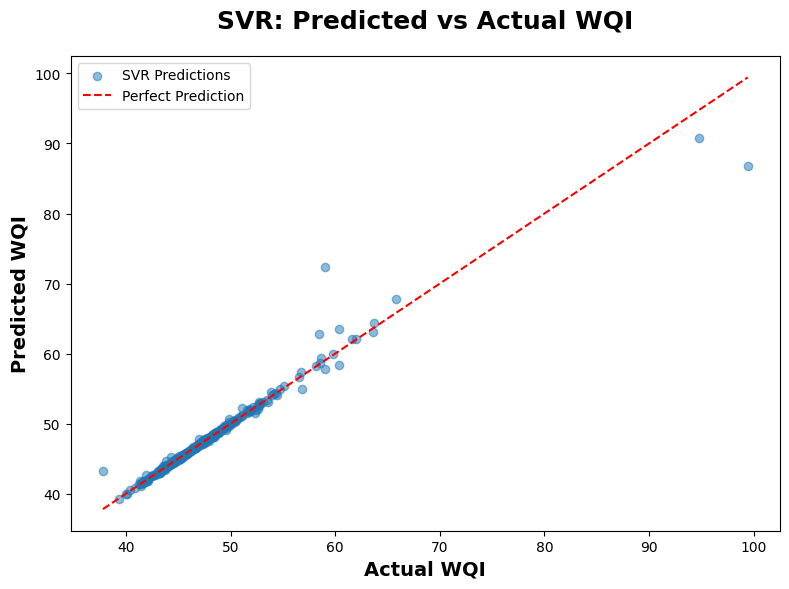

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label="SVR Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel('Actual WQI', fontsize= 14, weight='bold')
plt.ylabel('Predicted WQI', fontsize= 14, weight='bold')
plt.title('SVR: Predicted vs Actual WQI', fontsize= 18, weight='bold', pad=20)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/figures/SVR_preds.png", dpi=300, bbox_inches='tight')
plt.show()

Linear Regression Model

Fit the model using 5-fold cross-validation:

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=100)

r2   = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2').mean()
rmse = -cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error').mean()
mae  = -cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error').mean()

print(f"CV R²:   {r2:.4f}")
print(f"CV RMSE: {rmse:.4f}")
print(f"CV MAE:  {mae:.4f}")

CV R²:   0.7864
CV RMSE: 3.0003
CV MAE:  1.7542


Evaluate the model on test set using RMSE, MAE and R^2:

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred):.4f}")

Test R²:   0.8165
Test RMSE: 2.4582
Test MAE:  1.5674


Check the coefficients table:

In [ ]:
lr_model = pipeline.named_steps['model']

# Coefficients table
coef_table = pd.DataFrame({
    "Predictor": predictors,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_table)

# Intercept
print("Intercept:", lr_model.intercept_)

                                            Predictor  Coefficient
6                           Fluoride (mg/L) [Box-Cox]     3.289012
4                        Dissolved oxygen (DO) (mg/L)     3.121299
10                            Silica, reactive (mg/L)     2.260992
14                         Temperature, water (deg C)     2.078992
7   Inorganic nitrogen (nitrate and nitrite) (mg/L...     1.975865
8                  Kjeldahl nitrogen (mg/L) [Box-Cox]     1.778183
13                                     Sulfate (mg/L)     1.368452
3   Chlorophyll a, uncorrected for pheophytin (ug/...     1.149643
9                     Organic carbon (mg/L) [Box-Cox]     1.096815
5           Dissolved oxygen saturation (%) [Box-Cox]     0.679338
0                  Alkalinity, total (mg/L) [Box-Cox]     0.642003
16     Total Phosphorus, mixed forms (mg/L) [Box-Cox]     0.599004
17                                                 pH     0.598650
15       Total Nitrogen, mixed forms (mg/L) [Box-Cox]     0.54

Check the important predictors in the model:

In [ ]:
result_lr = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=100)

importance_df = pd.DataFrame({
    "Predictor": predictors,
    "Importance": result_lr.importances_mean
}).sort_values(by="Importance", ascending=False)

importance_df

,Predictor,Importance
1,Chloride (mg/L) [Box-Cox],0.876227
6,Fluoride (mg/L) [Box-Cox],0.715395
4,Dissolved oxygen (DO) (mg/L),0.632760
10,"Silica, reactive (mg/L)",0.296561
14,"Temperature, water (deg C)",0.241642
7,Inorganic nitrogen (nitrate and nitrite) (mg/L...,0.179479
8,Kjeldahl nitrogen (mg/L) [Box-Cox],0.163297
13,Sulfate (mg/L),0.116176
3,"Chlorophyll a, uncorrected for pheophytin (ug/...",0.062958
9,Organic carbon (mg/L) [Box-Cox],0.054041


Plot the predictions vs. the actual water quality index:

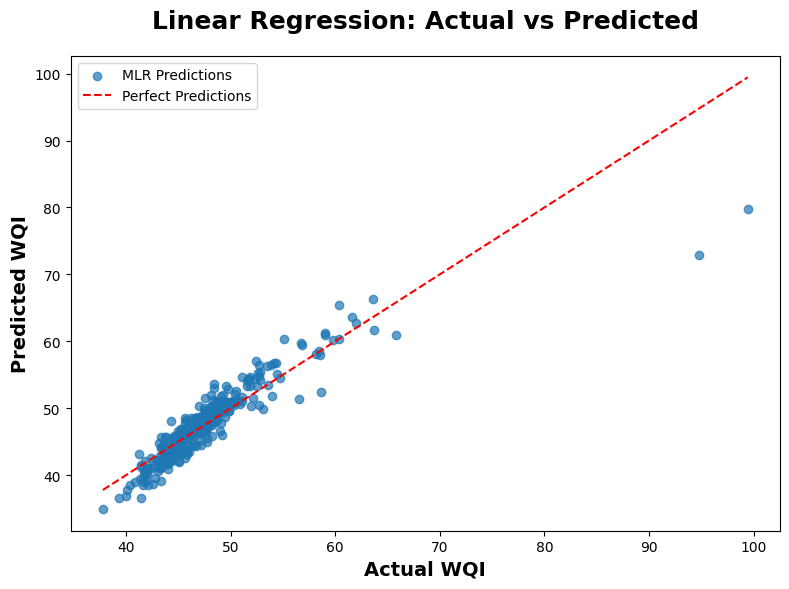

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label="MLR Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Predictions")
plt.xlabel("Actual WQI", fontsize=14, weight='bold')
plt.ylabel("Predicted WQI", fontsize=14, weight='bold')
plt.title("Linear Regression: Actual vs Predicted", fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.legend()
plt.savefig("/content/drive/MyDrive/figures/LR_preds.png", dpi=300, bbox_inches='tight')
plt.show()

Plot the residuals of the model:

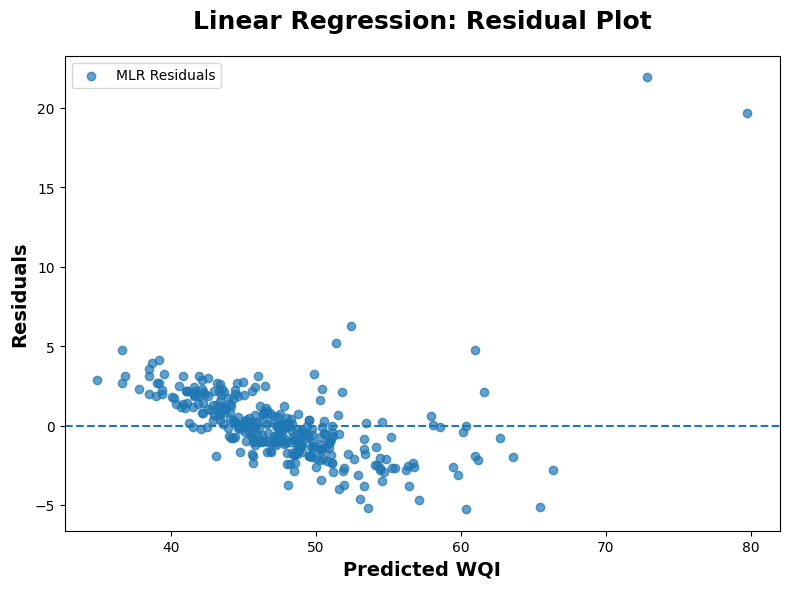

In [ ]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7, label="MLR Residuals")
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted WQI", fontsize= 14, weight='bold')
plt.ylabel("Residuals", fontsize= 14, weight='bold')
plt.title("Linear Regression: Residual Plot", fontsize= 18, weight='bold', pad=20)
plt.tight_layout()
plt.legend()
plt.savefig("/content/drive/MyDrive/figures/LR_residuals.png", dpi=300, bbox_inches='tight')
plt.show()

Deep Neural Network

Create Deep Neural Network with:

*   1e-4 L2 Regularization
*   Xavier Normal Initalization
*   Adam optimization with 1e-3 learning rate
*   3 hidden layers (neurons: 32, 64, 128)
*   ReLU activation
*   Mean Squared Error loss function
*   100 epochs



In [ ]:
input_dimensions = X_train_scaled.shape[1]

regular = keras.regularizers.L2(1e-4)
initializer = keras.initializers.GlorotNormal()
optimizer = keras.optimizers.Adam(1e-3)

model = keras.Sequential([
    layers.Input(shape=(input_dimensions,)),
    layers.Dense(32, activation=None, kernel_initializer=initializer, kernel_regularizer=regular),
    layers.Activation("relu"),
    layers.Dense(64, activation=None, kernel_initializer=initializer, kernel_regularizer=regular),
    layers.Activation("relu"),
    layers.Dense(128, activation=None, kernel_initializer=initializer, kernel_regularizer=regular),
    layers.Activation("relu"),
    layers.Dense(1, activation="linear")
])

model.compile(optimizer=optimizer, loss="mse", metrics=[keras.metrics.RootMeanSquaredError(name="rmse"), keras.metrics.MeanAbsoluteError(name="mae")])
history = model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, verbose=1, shuffle=True)
# history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=100, verbose=1, shuffle=True)

Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 570.7775 - mae: 17.5093 - rmse: 23.8906 - val_loss: 68.2278 - val_mae: 6.4675 - val_rmse: 8.2589
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 44.6656 - mae: 5.1509 - rmse: 6.6819 - val_loss: 32.6767 - val_mae: 4.3688 - val_rmse: 5.7147
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 23.1195 - mae: 3.6489 - rmse: 4.8063 - val_loss: 18.2017 - val_mae: 3.2237 - val_rmse: 4.2641
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 13.3806 - mae: 2.7126 - rmse: 3.6553 - val_loss: 10.6701 - val_mae: 2.4506 - val_rmse: 3.2635
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.6622 - mae: 2.1121 - rmse: 2.9398 - val_loss: 6.8352 - val_mae: 1.9135 - val_rmse: 2.6106
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2675 - mae: 1.7286 - rmse: 2.4994 - val_loss: 4.7718 - val_mae: 1.5678 - val_rmse: 2.1797
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.9705 - m

Evaluate the model on test set using RMSE, MAE and R^2:

In [ ]:
y_pred_net = model.predict(X_test_scaled)

mse  = mean_squared_error(y_test, y_pred_net)
mae  = mean_absolute_error(y_test, y_pred_net)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_net)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MAE: 0.4560562810934608
RMSE: 0.852548398890606
R2: 0.9779278079459772


Check the important predictors in the model:

In [ ]:
result_nn = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=100, scoring='r2')

importance_df = pd.DataFrame({
    "Predictor": predictors,
    "Importance": result_nn.importances_mean
}).sort_values(by="Importance", ascending=False)

importance_df

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


,Predictor,Importance
4,Dissolved oxygen (DO) (mg/L),0.539146
14,"Temperature, water (deg C)",0.319676
1,Chloride (mg/L) [Box-Cox],0.246243
6,Fluoride (mg/L) [Box-Cox],0.143508
0,"Alkalinity, total (mg/L) [Box-Cox]",0.125548
3,"Chlorophyll a, uncorrected for pheophytin (ug/...",0.121848
8,Kjeldahl nitrogen (mg/L) [Box-Cox],0.115418
12,Specific conductance (uS/cm) [Box-Cox],0.114469
7,Inorganic nitrogen (nitrate and nitrite) (mg/L...,0.096733
9,Organic carbon (mg/L) [Box-Cox],0.045910


Plot the predictions vs. actual water quality index:

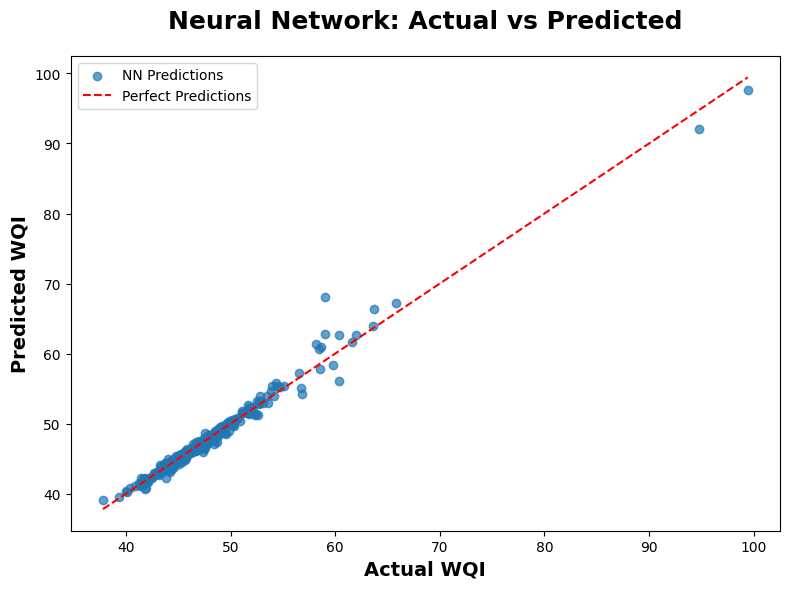

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_net, alpha=0.7, label="NN Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Predictions")
plt.xlabel("Actual WQI", fontsize= 14, weight='bold')
plt.ylabel("Predicted WQI", fontsize= 14, weight='bold')
plt.title("Neural Network: Actual vs Predicted", fontsize= 18, weight='bold', pad=20)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/figures/NN_preds.png", dpi=300, bbox_inches='tight')
plt.show()

Plot the training errors of the model:

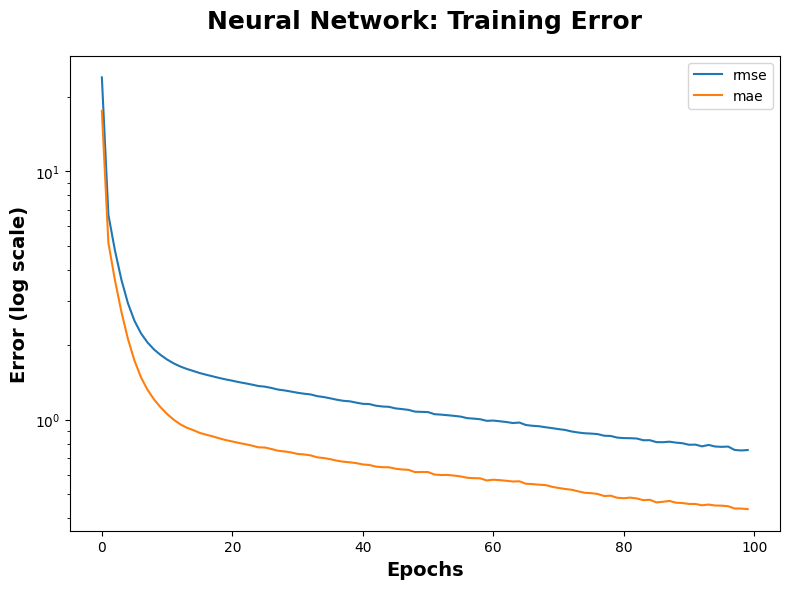

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["rmse"], label="rmse")
plt.plot(history.history["mae"], label="mae")
plt.xlabel("Epochs", fontsize=14, weight='bold')
plt.ylabel("Error (log scale)", fontsize=14, weight='bold')
plt.yscale('log')
plt.title("Neural Network: Training Error", fontsize=18, weight='bold', pad=20)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/figures/NN_train_errors.png", dpi=300, bbox_inches='tight')
plt.show()

Plot the validation errors of the model:

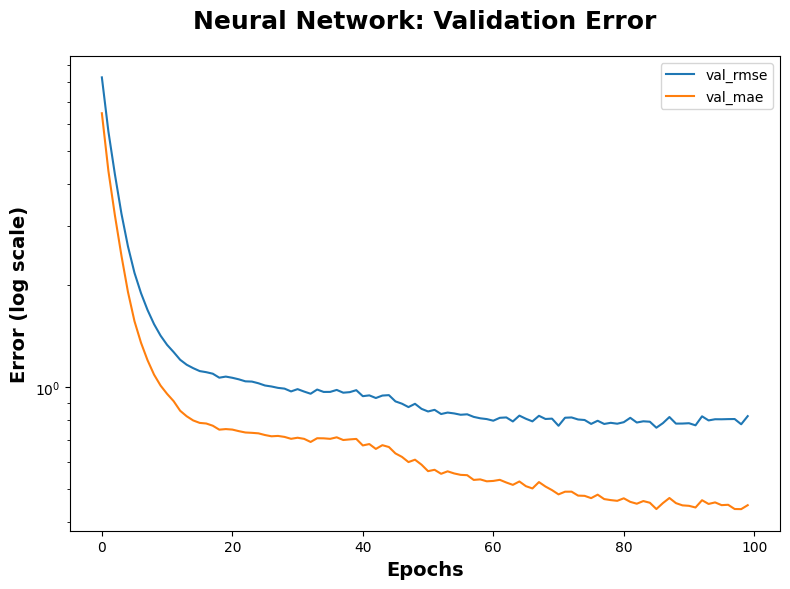

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["val_rmse"], label="val_rmse")
plt.plot(history.history["val_mae"], label="val_mae")
plt.xlabel("Epochs", fontsize=14, weight='bold')
plt.ylabel("Error (log scale)", fontsize=14, weight='bold')
plt.yscale('log')
plt.title("Neural Network: Validation Error", fontsize=18, weight='bold', pad=20)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/figures/NN_val_errors.png", dpi=300, bbox_inches='tight')
plt.show()

#Time Series Analysis

Create timeseries dataframe for analysis:

In [ ]:
# Sort by date
ts_global = dataset_clean[['ActivityStartDate', 'Water Quality Index (WQI)']].copy()
ts_global['ActivityStartDate'] = pd.to_datetime(ts_global['ActivityStartDate'])
ts_global = ts_global.groupby('ActivityStartDate')['Water Quality Index (WQI)'].mean().reset_index()
ts_global = ts_global.sort_values('ActivityStartDate').reset_index(drop=True)

# Apply rolling average to reduce spikes
ts_global['Water Quality Index (WQI)'] = ts_global['Water Quality Index (WQI)'].rolling(window=3, min_periods=1).mean()

print(f"Date range: {ts_global['ActivityStartDate'].min()} to {ts_global['ActivityStartDate'].max()}")
print(f"Total timesteps: {len(ts_global)}")
ts_global.head(10)

Date range: 2000-04-16 00:00:00 to 2024-09-23 00:00:00
Total timesteps: 805


,ActivityStartDate,Water Quality Index (WQI)
0,2000-04-16,50.033169
1,2000-04-17,49.600505
2,2000-04-18,50.980856
3,2000-04-19,51.340228
4,2000-04-20,51.123450
5,2000-05-01,49.461505
6,2000-05-02,48.126800
7,2000-05-03,48.297863
8,2000-05-04,47.170372
9,2000-05-05,47.075287


Plot the mean WQI over time to visualize the trend:

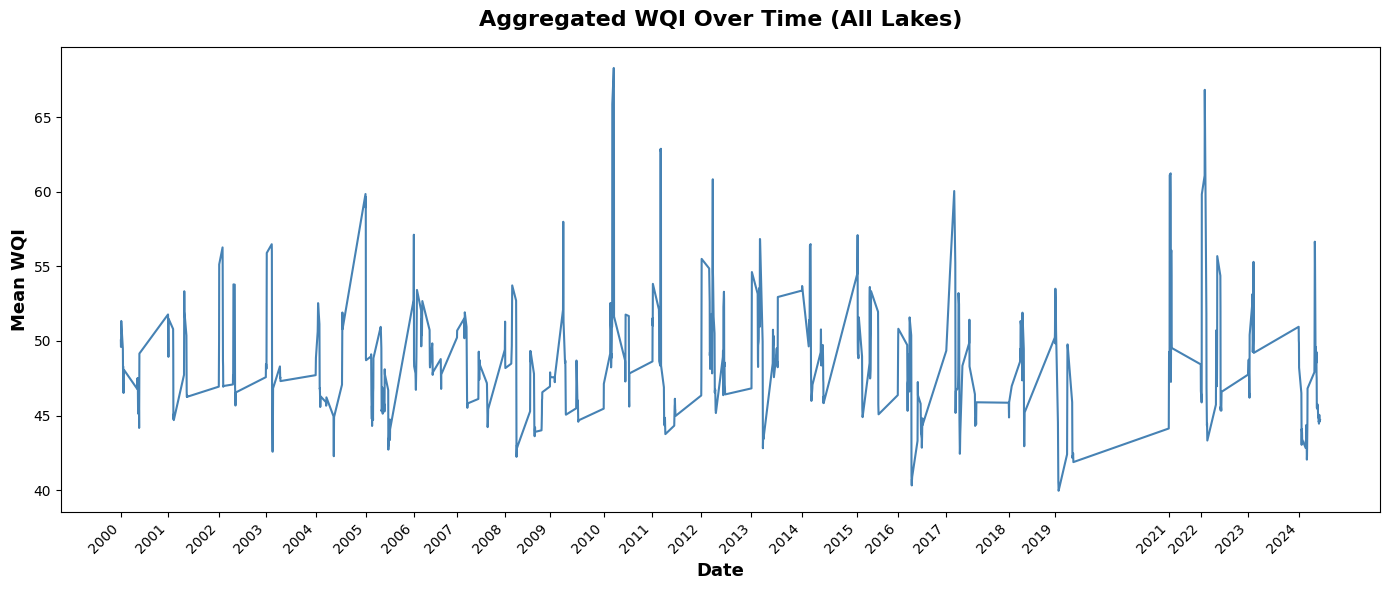

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(ts_global['ActivityStartDate'], ts_global['Water Quality Index (WQI)'], linewidth=1.5, color='steelblue')
plt.xlabel('Date', fontsize=13, weight='bold')
plt.ylabel('Mean WQI', fontsize=13, weight='bold')
plt.title('Aggregated WQI Over Time (All Lakes)', fontsize=16, weight='bold', pad=15)

# Show only years on x-axis
years = ts_global['ActivityStartDate'].dt.year.unique()
year_positions = [ts_global[ts_global['ActivityStartDate'].dt.year == year]['ActivityStartDate'].iloc[0] for year in sorted(years)]
plt.xticks(year_positions, sorted(years), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/ts_global_wqi.png', dpi=300, bbox_inches='tight')
plt.show()

Split the data into train and test splits using a 90/10 split:

In [ ]:
wqi_raw = ts_global['Water Quality Index (WQI)'].values

split = int(len(wqi_raw) * 0.9)
wqi_train = wqi_raw[:split]
wqi_test  = wqi_raw[split:]

print(f"Train size: {len(wqi_train)}, Test size: {len(wqi_test)}")

Train size: 724, Test size: 81


Scale the features from 0 to 1 for LSTM model:

In [ ]:
scaler_ts = MinMaxScaler()

wqi_train_scaled = scaler_ts.fit_transform(wqi_train.reshape(-1, 1)).flatten()
wqi_test_scaled  = scaler_ts.transform(wqi_test.reshape(-1, 1)).flatten()

print(f"Min scaled: {wqi_train_scaled.min():.4f}")
print(f"Max scaled: {wqi_train_scaled.max():.4f}")

Min scaled: 0.0000
Max scaled: 1.0000


Build sliding window sequences:

In [ ]:
LOOKBACK = 8

def create_sequences(series, lookback):
    X_seq, y_seq = [], []
    for i in range(len(series) - lookback):
        X_seq.append(series[i:i + lookback])
        y_seq.append(series[i + lookback])
    return np.array(X_seq), np.array(y_seq)

X_train, y_train = create_sequences(wqi_train_scaled, LOOKBACK)
X_test,  y_test  = create_sequences(wqi_test_scaled,  LOOKBACK)

X_train = X_train.reshape(-1, LOOKBACK, 1)
X_test  = X_test.reshape(-1, LOOKBACK, 1)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (716, 8, 1), y_train: (716,)
X_test:  (73, 8, 1),  y_test:  (73,)


Build the LSTM model for prediction using:

*   LSTM hidden layer with 16 neurons
*   Adam optimization with 5e-4 learning rate
*   Mean Squared Error loss function



In [ ]:
lstm_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(16),
    layers.Dense(1)
])

lstm_model.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM model with early stopping:

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_ts = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0519 - mae: 0.1716 - val_loss: 0.0396 - val_mae: 0.1533
Epoch 2/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0170 - mae: 0.0983 - val_loss: 0.0380 - val_mae: 0.1504
Epoch 3/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0163 - mae: 0.0959 - val_loss: 0.0365 - val_mae: 0.1474
Epoch 4/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0155 - mae: 0.0936 - val_loss: 0.0350 - val_mae: 0.1446
Epoch 5/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0148 - mae: 0.0913 - val_loss: 0.0335 - val_mae: 0.1414
Epoch 6/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0142 - mae: 0.0892 - val_loss: 0.0320 - val_mae: 0.1376
Epoch 7/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0135 - mae: 0.0871 - val_loss: 0.0304 - val_mae: 0.1331
Epoch 8/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0129 - mae: 0.0849 - val_loss: 0.0288 - val_mae: 0.1283
Epoch 9/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

Evaluate the model on the test set:

In [ ]:
y_pred = lstm_model.predict(X_test)

# Inverse transform back to original WQI scale
y_pred_inv = scaler_ts.inverse_transform(y_pred).flatten()
y_test_inv = scaler_ts.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae  = mean_absolute_error(y_test_inv, y_pred_inv)
r2   = r2_score(y_test_inv, y_pred_inv)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")
print(f"Test R²:   {r2:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Test RMSE: 1.2599
Test MAE:  0.8288
Test R²:   0.8749


Evaluate the model on the train set:

In [ ]:
y_train_pred = lstm_model.predict(X_train)

# Inverse transform back to original WQI scale
y_train_pred_inv = scaler_ts.inverse_transform(y_train_pred).flatten()
y_train_inv = scaler_ts.inverse_transform(y_train.reshape(-1, 1)).flatten()

train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
train_r2 = r2_score(y_train_inv, y_train_pred_inv)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MAE:  {train_mae:.4f}")
print(f"Train R²:   {train_r2:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Train RMSE: 1.8119
Train MAE:  0.9971
Train R²:   0.7879


Plot predictions vs actual water quality index over time:

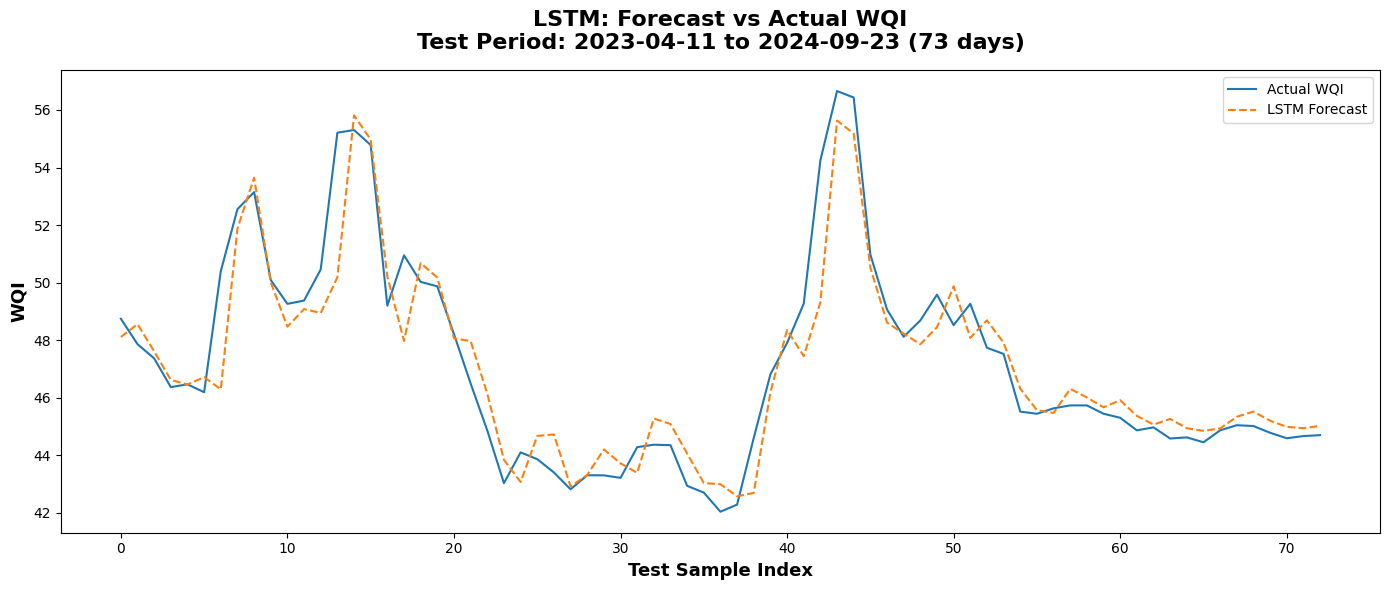

In [ ]:
plt.figure(figsize=(14, 6))

# Get test dates for reference
test_start_idx = split + LOOKBACK
test_dates = pd.to_datetime(ts_global['ActivityStartDate'].values[test_start_idx:test_start_idx + len(y_test_inv)])
date_range = f"{test_dates[0].strftime('%Y-%m-%d')} to {test_dates[-1].strftime('%Y-%m-%d')}"

plt.plot(y_test_inv, label='Actual WQI', linewidth=1.5)
plt.plot(y_pred_inv, label='LSTM Forecast', linewidth=1.5, linestyle='--')
plt.xlabel('Test Sample Index', fontsize=13, weight='bold')
plt.ylabel('WQI', fontsize=13, weight='bold')
plt.title(f'LSTM: Forecast vs Actual WQI\nTest Period: {date_range} ({len(test_dates)} days)', fontsize=16, weight='bold', pad=15)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/ts_lstm_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

Plot the training MSE loss curve of the model:

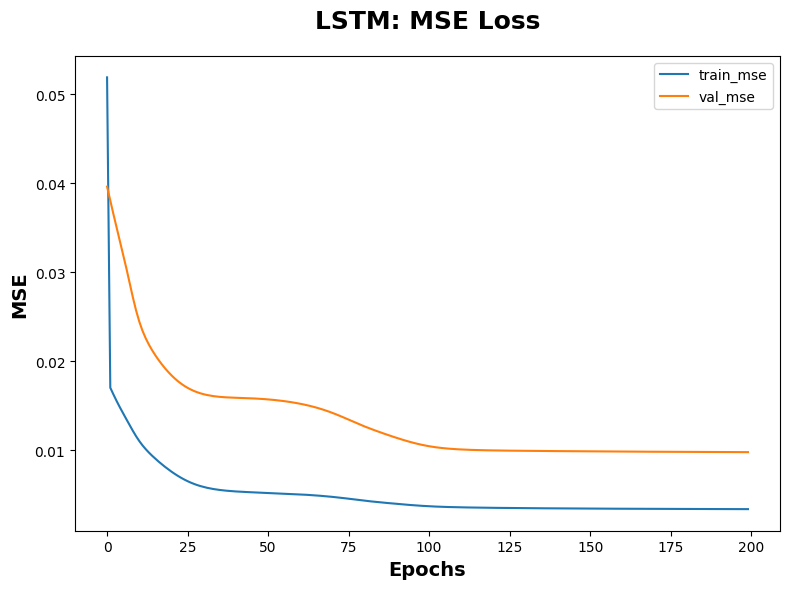

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history_ts.history['loss'], label='train_mse')
plt.plot(history_ts.history['val_loss'], label='val_mse')
plt.xlabel('Epochs', fontsize=14, weight='bold')
plt.ylabel('MSE', fontsize=14, weight='bold')
plt.title('LSTM: MSE Loss', fontsize=18, weight='bold', pad=20)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/ts_lstm_mse.png', dpi=300, bbox_inches='tight')
plt.show()

Plot the training MAE loss curve of the model:

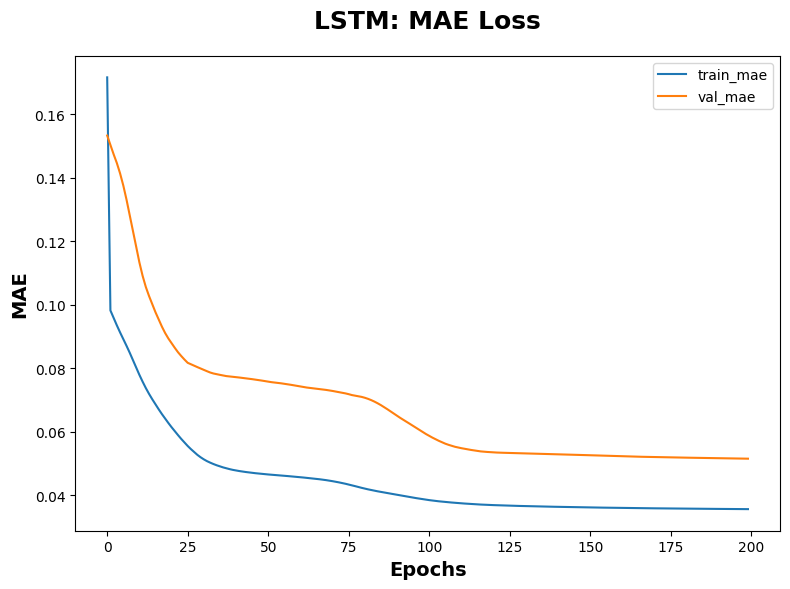

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history_ts.history['mae'], label='train_mae')
plt.plot(history_ts.history['val_mae'], label='val_mae')
plt.xlabel('Epochs', fontsize=14, weight='bold')
plt.ylabel('MAE', fontsize=14, weight='bold')
plt.title('LSTM: MAE Loss', fontsize=18, weight='bold', pad=20)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/ts_lstm_mae.png', dpi=300, bbox_inches='tight')
plt.show()